【Python セミナー 第2回 予習】  
#* の横に、このコードはどのような役割をになっているか簡単に記載してください。  
必要に応じてライブラリを追加してください。

In [17]:
#* 例) ライブラリのインポート
import numpy as np
import pandas as pd
from pandas.plotting import scatter_matrix
import matplotlib.pyplot as plt
import matplotlib.figure as figure
from matplotlib import rcParams
from sklearn import metrics
from sklearn.model_selection import train_test_split, cross_val_predict, RandomizedSearchCV, GridSearchCV
from sklearn.inspection import permutation_importance
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import Lasso

In [10]:
 #*　予測結果を評価し、実測値と予測値の散布図を表示する関数を定義する
def pred_plot(train_targets,train_predictions,test_targets,test_predictions,model_name):
    #* トレーニングデータに対する予測精度を RMSE・MAE・R2 で計算する
    train_mse = mean_squared_error(train_targets, train_predictions)
    train_mae = mean_absolute_error(train_targets, train_predictions)
    train_r2 = r2_score(train_targets, train_predictions)
    train_rmse = np.sqrt(train_mse)

    #* テストデータに対する予測精度を RMSE・MAE・R2 で計算する
    test_mse = mean_squared_error(test_targets, test_predictions)
    test_mae = mean_absolute_error(test_targets, test_predictions)
    test_r2 = r2_score(test_targets, test_predictions)
    test_rmse = np.sqrt(test_mse)

    print(f'\nMEGAN Training Set Performance:')
    print(f'Samples: {len(train_predictions)} | RMSE: {train_rmse:.4f} | MAE: {train_mae:.4f} | R²: {train_r2:.4f}')

    print(f'\nMEGAN Test Set Performance:')
    print(f'Samples: {len(test_predictions)} | RMSE: {test_rmse:.4f} | MAE: {test_mae:.4f} | R²: {test_r2:.4f}')

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

    #* トレーニングデータの実測値と予測値を散布図で比較する
    ax1.scatter(train_targets, train_predictions, alpha=0.6, color='red', s=20)
    train_range = np.linspace(train_targets.min(), train_targets.max())
    ax1.plot(train_range, train_range, 'k--', lw=2)
    ax1.set_xlabel('Calculated MEDV / eV')
    ax1.set_ylabel('Predicted MEDV / eV')
    ax1.set_title(f'{model_name} Training Set (n={len(train_predictions)})\nRMSE: {train_rmse:.3f} | MAE: {train_mae:.3f} | R²: {train_r2:.3f}')
    ax1.grid(True, alpha=0.3)
    ax1.set_aspect('equal', adjustable='box')

    #* テストデータの実測値と予測値を散布図で比較する
    ax2.scatter(test_targets, test_predictions, alpha=0.6, color='blue', s=20)
    test_range = np.linspace(test_targets.min(), test_targets.max())
    ax2.plot(test_range, test_range, 'k--', lw=2)
    ax2.set_xlabel('Calculated MEDV / eV')
    ax2.set_ylabel('Predicted MEDV / eV')
    ax2.set_title(f'{model_name} Test Set (n={len(test_predictions)})\nRMSE: {test_rmse:.3f} | MAE: {test_mae:.3f} | R²: {test_r2:.3f}')
    ax2.grid(True, alpha=0.3)
    ax2.set_aspect('equal', adjustable='box')

    plt.tight_layout()
    plt.subplots_adjust(wspace=0) 
    plt.show()

In [12]:
 #* どの特徴量が予測に強く影響したかを調べる関数を定義
def feature_importance(model,X,model_name):
    #*学習済みモデルから、それぞれの特徴量の重要度を取り出している
    importances = model.coef_
    feature_names = X.columns

    #* 特徴量の名前と重要度を表にまとめ、重要度が高い順に並べている
    feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
    feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

    #* 重要度が高い特徴量をグラフにして、どの情報が予測に役立ったか見やすくしている
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10),palette='viridis')
    plt.title(f'Feature Importances in {model_name}')
    plt.show()

In [13]:
 #*CSVファイルを読み込んで、分子のデータを表として表示している
df = pd.read_csv('boston.csv')
df


,Unnamed: 0,MEDV,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,sample_1,24.0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98
1,sample_2,21.6,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14
2,sample_3,34.7,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03
3,sample_4,33.4,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94
4,sample_5,36.2,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,sample_502,22.4,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,391.99,9.67
502,sample_503,20.6,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08
503,sample_504,23.9,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64
504,sample_505,22.0,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273,21.0,393.45,6.48


In [14]:
#* 予測に直接使わない列を取り除き、機械学習に使いやすいデータにしている
drop_list = ['Unnamed: 0']
df_clean = df.drop(columns=drop_list)
df_clean

,MEDV,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,24.0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98
1,21.6,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14
2,34.7,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03
3,33.4,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94
4,36.2,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,22.4,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,391.99,9.67
502,20.6,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08
503,23.9,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64
504,22.0,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273,21.0,393.45,6.48


In [8]:
 #*目的変数を medv に設定し、目的変数 y と説明変数 x に分ける
target = 'MEDV'
y = df_clean[target] 
x = df_clean.drop(columns=[target]) 

#* データをトレーニングデータ80%、テストデータ20%に分割する
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.20, shuffle=True,random_state=42) 

#*トレーニングデータの目的変数と説明変数を標準化する
auto_y_train = (y_train - y_train.mean()) / y_train.std()
auto_X_train = (X_train - X_train.mean()) / X_train.std()
#*テストデータの説明変数を、トレーニングデータの平均と標準偏差を使って標準化する
auto_X_test = (X_test - X_train.mean()) / X_train.std()

print(f'目的変数:{target},説明変数:{x.shape[1]},データ数:{x.shape[0]}')
print(f'トレーニングセット:{X_train.shape[0]},テストセット:{X_test.shape[0]}')

目的変数:MEDV,説明変数:13,データ数:506
トレーニングセット:404,テストセット:102



MEGAN Training Set Performance:
Samples: 404 | RMSE: 4.6524 | MAE: 3.3068 | R²: 0.7508

MEGAN Test Set Performance:
Samples: 102 | RMSE: 4.9314 | MAE: 3.1834 | R²: 0.6684


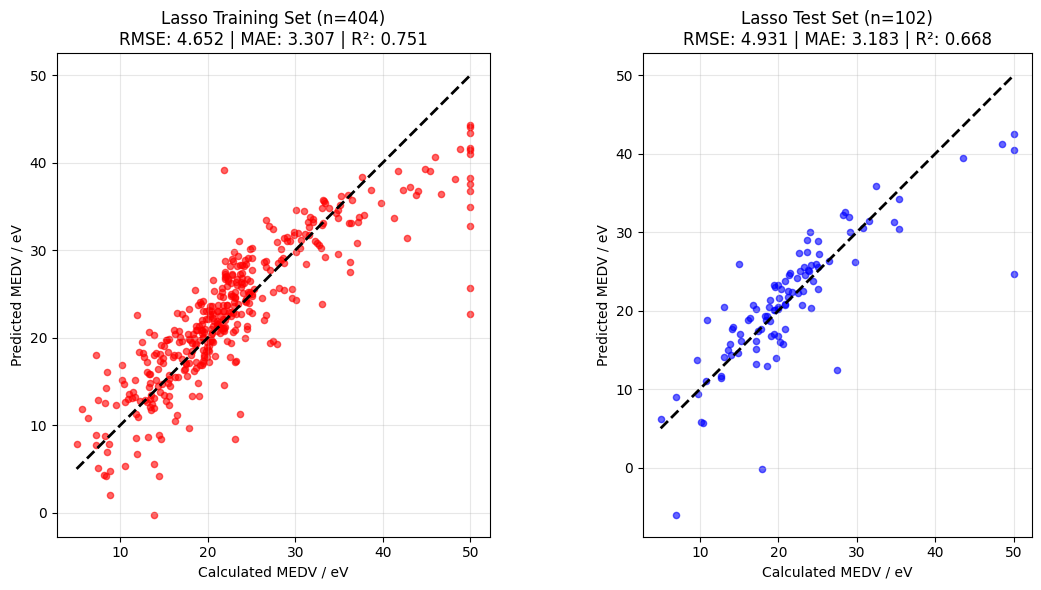

/var/folders/mw/1xx3mj955bn6l24bbqrbd3s00000gp/T/ipykernel_19344/719974688.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10),palette='viridis')


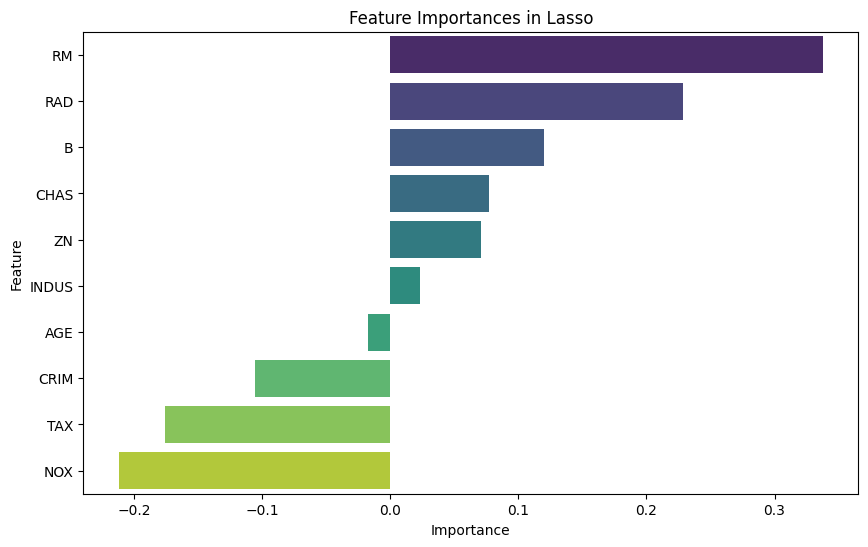

alpha = 0.0007345996550795484
coefficients: [-0.10546996  0.07104771  0.02312855  0.0772133  -0.21231051  0.33790832
 -0.01720449 -0.32548186  0.22826513 -0.17634604 -0.21726189  0.12031173
 -0.38732227]


In [22]:
 #Lasso回帰モデルを作成する
 #*Lasso 回帰モデルを作成する
model_name = 'Lasso'
from sklearn.linear_model import LassoCV
model = LassoCV(cv=5, random_state=42)

#* 標準化したトレーニングデータを使ってモデルを学習させる
model.fit(auto_X_train,auto_y_train)

#* トレーニングデータに対して予測を行い、標準化された予測値を元のスケールに戻す
autoscaled_pred_y_train = model.predict(auto_X_train)  
pred_y_train = autoscaled_pred_y_train * y_train.std() + y_train.mean() #*
pred_y_train = pd.DataFrame(pred_y_train, index=auto_X_train.index, columns=['pred_y'])

#* テストデータに対して予測を行い、標準化された予測値を元のスケールに戻す
autoscaled_pred_y_test = model.predict(auto_X_test)  
pred_y_test = autoscaled_pred_y_test * y_train.std() + y_train.mean() #* (pred_y_trainと同じ)
pred_y_test = pd.DataFrame(pred_y_test, index=X_test.index, columns=['pred_y'])

pred_plot(y_train,pred_y_train,y_test,pred_y_test,model_name) #* 実測値と予測値を比較する散布図を表示し、予測精度を確認する
feature_importance(model,auto_X_train,model_name) #* 学習済みモデルにおける説明変数の重要度を表示する
print("alpha =", model.alpha_)
print("coefficients:", model.coef_)

第二回の宿題はここまでです。
余裕があればこの下もやってみてください。第3回で勉強する範囲です。

早期停止が実行されたイテレーション数: 1038

MEGAN Training Set Performance:
Samples: 8000 | RMSE: 0.1267 | MAE: 0.0662 | R²: 0.9673

MEGAN Test Set Performance:
Samples: 2000 | RMSE: 0.2510 | MAE: 0.1830 | R²: 0.8661


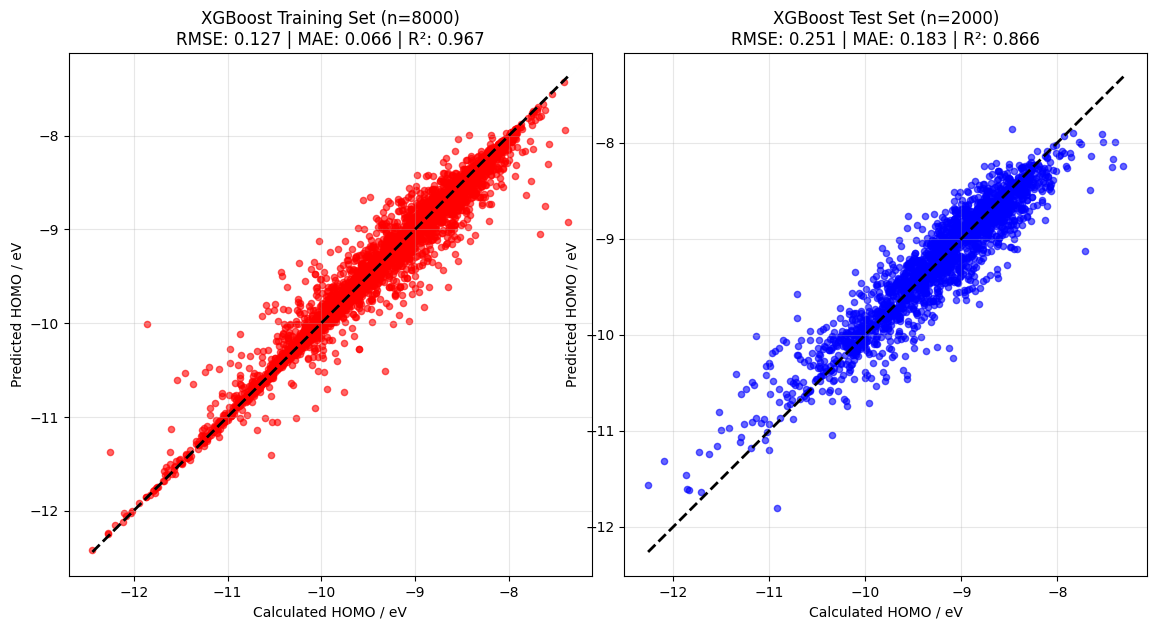

/var/folders/2r/2w6_2by54h92_12v16pjtjr00000gp/T/ipykernel_15998/2309135372.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10),palette='viridis')


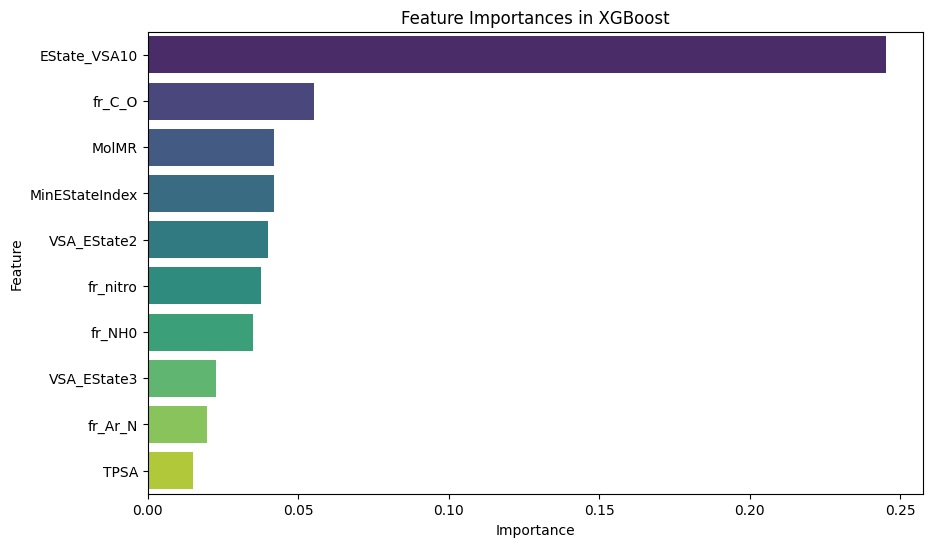

In [ ]:
#*
model_name = 'XGBoost'
X_trainXGB, X_valid, y_trainXGB, y_valid = train_test_split(auto_X_train, auto_y_train, test_size=0.2, shuffle=True,random_state=42)

model = model = xgb.XGBRegressor(
    n_estimators=10000, 
    learning_rate=0.05,
    random_state=42,
    eval_metric='rmse',  
    early_stopping_rounds=50, 
)
model.fit(
    X_trainXGB,y_trainXGB,
    eval_set=[(X_valid,y_valid)],
    verbose=0
)
autoscaled_pred_y_train = model.predict(auto_X_train)  # y の推定
pred_y_train = autoscaled_pred_y_train * y_train.std() + y_train.mean() #スケールを元に戻す
pred_y_train = pd.DataFrame(pred_y_train, index=auto_X_train.index, columns=['pred_y'])

 #*
stopped_at = model.best_iteration
print(f"早期停止が実行されたイテレーション数: {stopped_at}")
#*
autoscaled_pred_y_test = model.predict(auto_X_test)  # y の推定
pred_y_test = autoscaled_pred_y_test * y_train.std() + y_train.mean() #*スケールを元に戻す
pred_y_test = pd.DataFrame(pred_y_test, index=X_test.index, columns=['pred_y'])

pred_plot(y_train,pred_y_train,y_test,pred_y_test,model_name)
feature_importance(model,X_trainXGB,model_name)